In [1]:
import pandas as pd

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.ml.shallow_autoencoder.alpha_scheduler import ConstantAlphaScheduler, LinearAlphaScheduler, \
    GeometricAlphaScheduler, AdaptiveAlphaScheduler, AlphaSchedulerArgs, AlphaSchedulerFactory
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [3]:
exp_weight_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "exp_template"
baseline: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline"


In [4]:
baseline_recalls, baseline_precisions = get_precisions_recalls(baseline)
exp_weight_recalls, exp_weight_precisions = get_precisions_recalls(exp_weight_path)

In [5]:
print(f"Baseline recall: {np.array(baseline_recalls).mean(axis=0)}")
print(f"Exp weight recall: {np.array(exp_weight_recalls).mean(axis=0)}")

Baseline recall: [3.12075052e-05 3.09546501e-02 1.27430414e-01 2.24620259e-01
 3.10711362e-01 3.84651217e-01 4.48944917e-01 5.03436012e-01
 5.53600796e-01 6.06030703e-01 6.57547169e-01 7.03190888e-01
 7.41921737e-01 7.74804656e-01 8.00482675e-01 8.21350049e-01
 8.37900337e-01 8.51987032e-01 8.64264165e-01 8.75441498e-01
 8.85209685e-01 8.93955572e-01 9.02118299e-01 9.09823641e-01
 9.16743273e-01 9.23415361e-01 9.28908504e-01 9.33978552e-01
 9.38015179e-01 9.41959181e-01 9.45461534e-01 9.48885132e-01
 9.51784757e-01 9.54099198e-01 9.56051271e-01 9.58026808e-01
 9.60086029e-01 9.61904085e-01 9.63673826e-01 9.65015782e-01
 9.66433119e-01 9.67556939e-01 9.68657939e-01 9.69598676e-01
 9.70360089e-01 9.71071515e-01 9.71852127e-01 9.72641866e-01
 9.73290874e-01 9.74257364e-01 9.74934795e-01 9.75679848e-01
 9.76271123e-01 9.76934231e-01 9.77525815e-01 9.78155392e-01
 9.78827136e-01 9.79450759e-01 9.79971293e-01 9.80425002e-01
 9.80963221e-01 9.81384816e-01 9.81975128e-01 9.82452377e-01
 9.8304

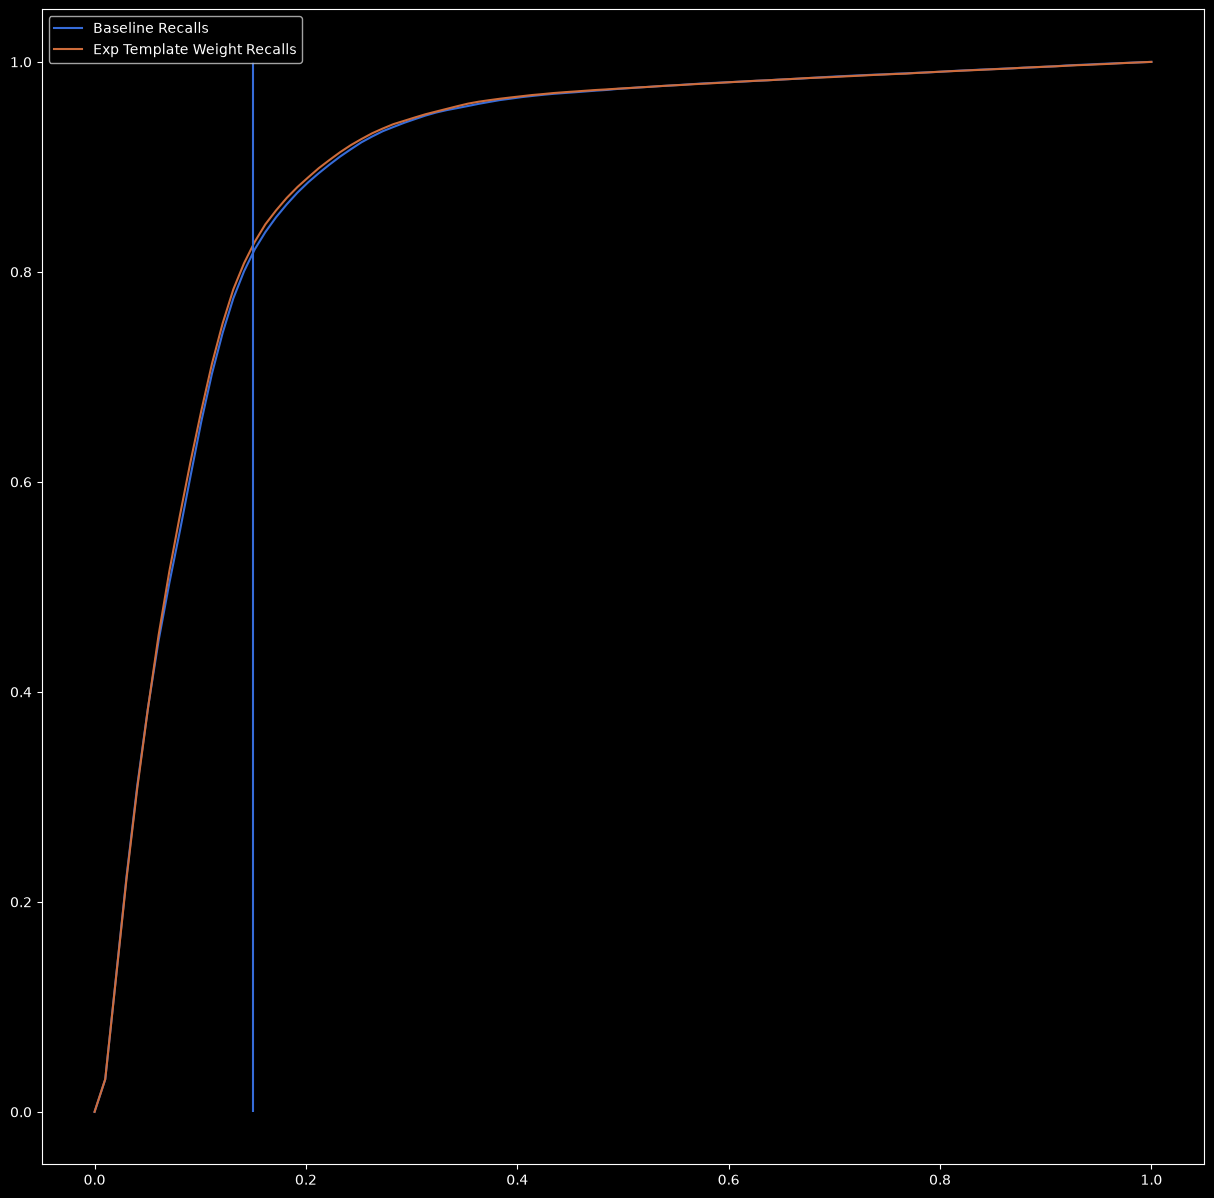

In [6]:
plt.figure(figsize=(15, 15))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(exp_weight_recalls).mean(axis=0),
         label="Exp Template Weight Recalls")


plt.vlines(x=0.15, ymin=0, ymax=1)
plt.legend()
plt.show()

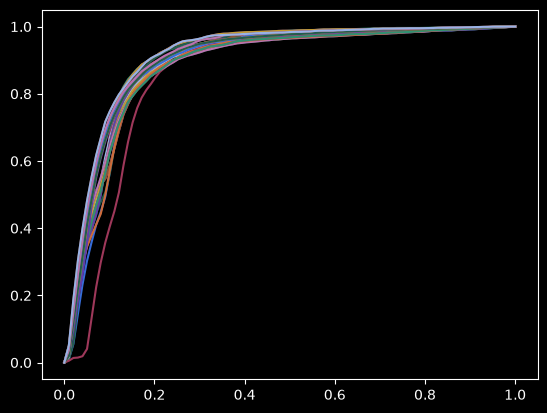

In [7]:
for i in range(30):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls)[i],
         label="Baseline Alpha Recalls")

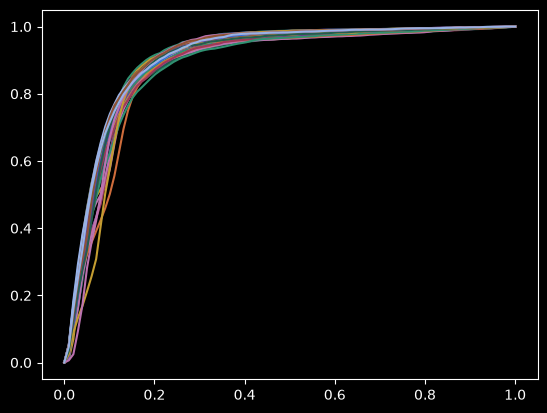

In [8]:
for i in range(len(exp_weight_recalls)):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(exp_weight_recalls)[i],
         label="Exp Template Weight Recalls")

In [11]:
 np.array(baseline_recalls).mean(axis=0)[25]

np.float64(0.9234153605257699)

In [12]:
 np.array(exp_weight_recalls).mean(axis=0)[25]

np.float64(0.9265246441747456)

$$s_j(t) = \alpha \phi_j p_j + (1-\alpha)\sigma(\gamma(t)x(t)^{T}B_{E,D})$$